# Cavity figures of merit: validation

In this benchmark we compute the figures of merit of cavity eigenmodes (R/Q, geometry
factor, wall and dielectric Q, external Q, peak fields, transverse kick, cell coupling)
and check each one against an independent answer: the closed-form pillbox modes, the
direct Lorentz-force integral, the same structure solved in one piece, and cavsim2d,
including its port boundary condition.

**Prerequisites:** [Find resonances and look at fields](../basics/resonances_and_fields.ipynb).
The notebook runs in about three minutes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import trapezoid
from scipy.special import j0, j1, jv

from cavsim3d.core.constants import c0, eps0, mu0
from cavsim3d.core.em_project import EMProject

eta = mu0 * c0                      # impedance of free space
chi01, chi11 = 2.404825557695773, 3.831705970207512
summary = {}                        # |difference| [%] of every check, for section 7

## 1. A pillbox cavity with beam pipes

### 1.1 Build and solve it

A pillbox of radius 100 mm and length 80 mm, with 15 mm beam pipes 80 mm long on both
sides. The pipe ends are the ports; far below the pipe cutoff the cavity modes are
those of the closed pillbox, perturbed only by the two holes.

In [2]:
R, L, r_pipe, L_pipe = 0.100, 0.080, 0.015, 0.080          # m
proj = EMProject(name="pillbox_fom", base_dir="./simulations", overwrite=True)
proj.create_primitive("pillbox", name="cavity", n_cells=1,
                      dims=[L, R, r_pipe, 0, L_pipe], beampipe="both", unit="m")
proj.generate_mesh(maxh=0.015)
proj.fds.solve(config=dict(fmin=0.8, fmax=2.0, nsamples=11, order=2, nportmodes=1,
                           solver_type="direct"))
rom = proj.fds.fom.reduce(tol=1e-10)

✅ Creating new project 'pillbox_fom' at simulations\pillbox_fom



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 4589



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


...

  
Coupled solve complete: 2 external ports in 7.31s


Saved port modes to simulations\pillbox_fom\fds\port_modes\port_modes.pkl



Model Order Reduction


Reduction complete: 33622 -> 17 DOFs (99.9% compression)


Saved port modes to simulations\pillbox_fom\fds\port_modes\port_modes.pkl


### 1.2 Find the TM010 and TM110 modes

In [3]:
f = proj.fds.get_resonant_frequencies()
f010 = chi01 * c0 / (2 * np.pi * R)
f110 = chi11 * c0 / (2 * np.pi * R)
i010 = int(np.argmin(np.abs(f - f010)))
i110 = int(np.argmin(np.abs(f - f110)))
print(f"TM010: mode {i010} at {f[i010] / 1e9:.5f} GHz (closed pillbox {f010 / 1e9:.5f} GHz)")
print(f"TM110: mode {i110} at {f[i110] / 1e9:.5f} GHz (closed pillbox {f110 / 1e9:.5f} GHz)")

TM010: mode 0 at 1.15013 GHz (closed pillbox 1.14743 GHz)
TM110: mode 2 at 1.82201 GHz (closed pillbox 1.82824 GHz)


The holes raise TM010 by 0.24 % and lower TM110 by 0.34 %.

## 2. TM010 against the closed form

### 2.1 Compute the figures of merit

The beam line runs parallel to the axis at x = 30 mm, clear of the beam-pipe holes, and
`Eacc` is normalised to the cavity length.

In [4]:
x0 = 0.030
fm = proj.fds.get_figures_of_merit(i010, offset=(x0, 0.0), active_length=L)
for key in ("freq [MHz]", "R/Q [Ohm]", "G [Ohm]", "Q []", "Rsh [MOhm]",
            "Epk/Eacc []", "Bpk/Eacc [mT/MV/m]", "k_loss [V/pC]"):
    print(f"{key:20s} {fm[key]:12.5g}")

freq [MHz]                 1150.1
R/Q [Ohm]                   164.2
G [Ohm]                    200.57
Q []                        22979
Rsh [MOhm]                 3.7731
Epk/Eacc []                1.3446
Bpk/Eacc [mT/MV/m]         2.6384
k_loss [V/pC]             0.29664


### 2.2 Compare with the closed form

For TM010, $E_z = E_0 J_0(\chi_{01} r/R)$. With transit-time factor $T$:

- $G = \chi_{01}\,\eta\,L / (2(L + R))$,
- $R/Q = 2 L\,T^2 J_0(\chi_{01} x_0/R)^2 / (\omega\,\varepsilon_0\,\pi R^2 J_1(\chi_{01})^2)$
  on the line at $x_0$,
- $B_{pk}/E_{acc} = \mu_0 \max J_1 / (\eta\,T\,J_0(\chi_{01} x_0/R))$, with the peak of
  $H_\varphi$ on the end walls at $\max J_1 = 0.58187$.

In [5]:
w = 2 * np.pi * f010
T = np.sin(w * L / (2 * c0)) / (w * L / (2 * c0))
exact = {
    "G [Ohm]": chi01 * eta * L / (2 * (L + R)),
    "R/Q [Ohm]": 2 * L * T ** 2 * j0(chi01 * x0 / R) ** 2
                 / (w * eps0 * np.pi * R ** 2 * j1(chi01) ** 2),
    "Bpk/Eacc [mT/MV/m]": mu0 * 0.581865 / (eta * T * j0(chi01 * x0 / R)) * 1e9,
}
print(f"{'':20s} {'computed':>10s} {'exact':>10s} {'diff':>8s}")
for key, ref in exact.items():
    diff = (fm[key] / ref - 1) * 100
    summary[f"TM010 {key.split(' ')[0]} vs closed form"] = abs(diff)
    print(f"{key:20s} {fm[key]:10.4f} {ref:10.4f} {diff:+7.2f} %")

                       computed      exact     diff
G [Ohm]                200.5694   201.3268   -0.38 %
R/Q [Ohm]              164.1983   164.4613   -0.16 %
Bpk/Eacc [mT/MV/m]       2.6384     2.6040   +1.32 %


G and R/Q agree to 0.4 % and 0.2 %. The peak magnetic field is a maximum of the
discrete field rather than an integral, and with these second-order elements it is 1.3 %
high.

### 2.3 Check that the reduced model gives the same numbers

In [6]:
fm_rom = rom.get_figures_of_merit(int(np.argmin(np.abs(rom.get_resonant_frequencies() - f010))),
                                  offset=(x0, 0.0), active_length=L)
for key in ("freq [MHz]", "R/Q [Ohm]", "G [Ohm]", "Epk/Eacc []", "Bpk/Eacc [mT/MV/m]"):
    print(f"{key:20s} ROM / FOM - 1 = {fm_rom[key] / fm[key] - 1:+.1e}")
summary["ROM vs FOM (largest)"] = 100 * max(
    abs(fm_rom[k] / fm[k] - 1) for k in ("R/Q [Ohm]", "G [Ohm]", "Bpk/Eacc [mT/MV/m]"))

freq [MHz]           ROM / FOM - 1 = +8.3e-08
R/Q [Ohm]            ROM / FOM - 1 = -1.1e-06
G [Ohm]              ROM / FOM - 1 = -8.7e-07
Epk/Eacc []          ROM / FOM - 1 = -3.6e-05
Bpk/Eacc [mT/MV/m]   ROM / FOM - 1 = -1.4e-04


The reduced model gives the full-order figures to 2e-4 or better.

## 3. A lossy filling: the dielectric Q

### 3.1 Fill the pillbox with a lossy dielectric

A uniform filling with loss tangent $\tan\delta$ takes the fraction $\tan\delta$ of the
stored energy per radian: $Q_{diel} = 1/\tan\delta$ exactly, whatever the mode.

In [7]:
proj_d = EMProject(name="pillbox_filled", base_dir="./simulations", overwrite=True)
filled = proj_d.create_primitive("pillbox", name="cavity", n_cells=1,
                                 dims=[L, R, r_pipe, 0, L_pipe], beampipe="both", unit="m")
filled.set_materials({"*": {"eps_r": 2.0, "tan_delta": 1e-3}})
proj_d.generate_mesh(maxh=0.02)
proj_d.fds.solve(config=dict(fmin=0.6, fmax=1.2, nsamples=7, order=2, nportmodes=1,
                             solver_type="direct"))
f_d = proj_d.fds.get_resonant_frequencies()
fm_d = proj_d.fds.get_figures_of_merit(int(np.argmin(np.abs(f_d - f010 / np.sqrt(2)))))
for key in ("freq [MHz]", "Q_diel []", "Q_wall []", "Q []", "G [Ohm]"):
    print(f"{key:12s} {fm_d[key]:12.6g}")
print(f"1/Q - (1/Q_wall + 1/Q_diel) = {1 / fm_d['Q []'] - 1 / fm_d['Q_wall []'] - 1 / fm_d['Q_diel []']:.1e}")
summary["Q_diel vs 1/tan(delta)"] = abs(fm_d["Q_diel []"] / 1e3 - 1) * 100

✅ Creating new project 'pillbox_filled' at simulations\pillbox_filled



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 2655



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


...

Saved port modes to simulations\pillbox_filled\fds\port_modes\port_modes.pkl

FDS Solve: 0.6000 - 1.2000 GHz, 7 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 3.59s


Saved port modes to simulations\pillbox_filled\fds\port_modes\port_modes.pkl


freq [MHz]        813.284
Q_diel []            1000
Q_wall []         19198.3
Q []              950.491
G [Ohm]            140.91
1/Q - (1/Q_wall + 1/Q_diel) = 0.0e+00


`Q_diel` is 1000 to rounding, and the unloaded `Q` combines the wall and dielectric
parts. The filling lowers the frequency by $\sqrt{2}$, and G with it.

## 4. The dipole mode TM110: the transverse kick

### 4.1 Compare the transverse R/Q with the closed form

A dipole mode has no voltage on the axis but kicks the beam sideways. The transverse
voltage comes from the gradient of the longitudinal voltage (Panofsky–Wenzel). For
TM110, $E_z = E_0 J_1(\chi_{11} r/R)\cos\varphi$, so
$V_t = (c/\omega)\,E_0 L T \chi_{11}/(2R)$ and
$U = \varepsilon_0 E_0^2 L \pi R^2 J_2(\chi_{11})^2/4$.

In [8]:
w1 = 2 * np.pi * f110
T1 = np.sin(w1 * L / (2 * c0)) / (w1 * L / (2 * c0))
vt_per_e0 = c0 / w1 * L * T1 * chi11 / (2 * R)
u_per_e0 = eps0 * L * np.pi * R ** 2 * jv(2, chi11) ** 2 / 4
rqt_exact = vt_per_e0 ** 2 / (w1 * u_per_e0)
pair = np.argsort(np.abs(f - f110))[:2]                    # the two polarisations
for i in sorted(pair):
    fm_i = proj.fds.get_figures_of_merit(int(i))
    diff = (fm_i["R/Q_t [Ohm]"] / rqt_exact - 1) * 100
    summary[f"TM110 R/Q_t vs closed form (mode {i})"] = abs(diff)
    print(f"mode {i}: R/Q_t = {fm_i['R/Q_t [Ohm]']:.3f} Ohm, closed form {rqt_exact:.3f} Ohm "
          f"({diff:+.2f} %), R/Q on the axis = {fm_i['R/Q [Ohm]']:.1e} Ohm")
fm_t = proj.fds.get_figures_of_merit(i110)
print(f"TM010 on the axis: R/Q_t = "
      f"{proj.fds.get_figures_of_merit(i010)['R/Q_t [Ohm]']:.1e} Ohm")

mode 1: R/Q_t = 62.611 Ohm, closed form 65.607 Ohm (-4.57 %), R/Q on the axis = 2.9e-05 Ohm


mode 2: R/Q_t = 62.948 Ohm, closed form 65.607 Ohm (-4.05 %), R/Q on the axis = 2.3e-07 Ohm


TM010 on the axis: R/Q_t = 1.6e-02 Ohm


Both polarisations are below the closed form, which ignores the beam-pipe holes: the
holes perturb the field near the axis, where the gradient is taken. With these
second-order elements the two polarisations also differ from each other; with
`order=3` both come within 2 % of the closed form. The monopole TM010 gives a transverse
R/Q about 4000 times smaller.

### 4.2 Compare with the Lorentz force along the axis

Panofsky–Wenzel is exact when the field vanishes at both ends of the line. Integrate the
transverse Lorentz force directly, $V_t = \int (\mathbf{E} + c\,\hat z\times\mathbf{B})_t
\,e^{j\omega z/c}\,dz$ with $\mathbf{B} = j\,\nabla\times\mathbf{E}/\omega$, on the
eigenmode field scaled to a stored energy of 1 J.

In [9]:
from ngsolve import InnerProduct, Integrate, curl

freq, E = proj.fds.get_eigenmode(i110)
mesh = proj.fds.mesh
w1 = 2 * np.pi * freq
U = 0.5 * eps0 * Integrate(InnerProduct(E, E), mesh)
zmin, zmax = mesh.ngmesh.Coordinates()[:, 2].min(), mesh.ngmesh.Coordinates()[:, 2].max()
z = np.linspace(zmin + 1e-9, zmax - 1e-9, 4001)
points = mesh(np.zeros_like(z), np.zeros_like(z), z)
Ez = np.asarray(E(points)).reshape(-1, 3)
Bz = 1j * np.asarray(curl(E)(points)).reshape(-1, 3) / w1
phase = np.exp(1j * w1 * z / c0)
v_x = trapezoid((Ez[:, 0] - c0 * Bz[:, 1]) * phase, z)
v_y = trapezoid((Ez[:, 1] + c0 * Bz[:, 0]) * phase, z)
vt_direct = np.hypot(abs(v_x), abs(v_y)) / np.sqrt(U)
diff = (fm_t["Vt [MV]"] * 1e6 / vt_direct - 1) * 100
summary["TM110 Vt: Panofsky-Wenzel vs Lorentz force"] = abs(diff)
print(f"Vt Panofsky-Wenzel {fm_t['Vt [MV]'] * 1e6:.5e} V, Lorentz force {vt_direct:.5e} V "
      f"({diff:+.2f} %)")

Vt Panofsky-Wenzel 8.48897e+05 V, Lorentz force 8.43692e+05 V (+0.62 %)


The two agree to 0.6 %. The rest is the finite-difference gradient and the
second-order field; with `order=3` the difference falls to 0.15 %.

## 5. Joined models against the one-piece model

### 5.1 Solve the reference in one piece

The join now has to pass the field through a beam pipe, so the pipes are widened to
30 mm and carry three modes (the two TE11 polarisations and TM01) at every port.
The reference is the cavity with 40 mm pipes, solved in one piece.

In [10]:
r_wide = 0.030
cfg = dict(fmin=0.9, fmax=1.4, nsamples=11, order=2, nportmodes=3, solver_type="direct")
proj_ref = EMProject(name="pillbox_one_piece", base_dir="./simulations", overwrite=True)
proj_ref.create_primitive("pillbox", name="cavity", n_cells=1,
                          dims=[L, R, r_wide, 0, 0.040], beampipe="both", unit="m")
proj_ref.generate_mesh(maxh=0.02)
proj_ref.fds.solve(config=cfg)
rom_ref = proj_ref.fds.fom.reduce(tol=1e-10)
f_ref = rom_ref.get_resonant_frequencies()
fm_ref = rom_ref.get_figures_of_merit(int(np.argmin(np.abs(f_ref - f010))),
                                      offset=(0.05, 0.0), active_length=L)

✅ Creating new project 'pillbox_one_piece' at simulations\pillbox_one_piece



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 1566



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


...

  
Coupled solve complete: 2 external ports in 1.90s


Saved port modes to simulations\pillbox_one_piece\fds\port_modes\port_modes.pkl



Model Order Reduction


Reduction complete: 11864 -> 38 DOFs (99.7% compression)


Saved port modes to simulations\pillbox_one_piece\fds\port_modes\port_modes.pkl


### 5.2 Glue three parts into one mesh

A 20 mm pipe, the cavity with 20 mm pipes, and another 20 mm pipe: the same structure as
three glued parts, each solved as its own domain, reduced and joined.

In [11]:
proj_g = EMProject(name="pillbox_glued", base_dir="./simulations", overwrite=True)
proj_g.create_primitive("beampipe", name="pipe_in", R=r_wide, L=0.020, unit="m")
proj_g.create_primitive("pillbox", name="cavity", n_cells=1,
                        dims=[L, R, r_wide, 0, 0.020], beampipe="both", unit="m")
proj_g.create_primitive("beampipe", name="pipe_out", R=r_wide, L=0.020, unit="m")
proj_g.generate_mesh(maxh=0.02)
proj_g.fds.solve(config=dict(cfg, per_domain=True, store_snapshots=True, global_method=None))
concat_g = proj_g.fds.foms.reduce(tol=1e-10).concatenate()
f_g = concat_g.get_resonant_frequencies()
fm_g = concat_g.get_figures_of_merit(int(np.argmin(np.abs(f_g - f010))),
                                     offset=(0.05, 0.0), active_length=L)
for key in ("freq [MHz]", "R/Q [Ohm]", "G [Ohm]", "Q []"):
    diff = (fm_g[key] / fm_ref[key] - 1) * 100
    summary[f"glued {key.split(' ')[0]} vs one piece"] = abs(diff)
    print(f"{key:12s} one piece {fm_ref[key]:10.4f}  glued {fm_g[key]:10.4f}  ({diff:+.3f} %)")

✅ Creating new project 'pillbox_glued' at simulations\pillbox_glued


Main axis: Z (default). Parts follow the list order along +Z:
  1. pipe_in: z = [-0.01, 0.01] m
  2. cavity: z = [0.01, 0.13] m
  3. pipe_out: z = [0.13, 0.15] m
Mesh strategy: glued (one conformal mesh of all parts; all parts are geometry, each used once)

Assembly domain-material mapping:
  pipe_in: ['pipe_in/vacuum']
  cavity: ['cavity/vacuum']
  pipe_out: ['pipe_out/vacuum']
Port naming complete:
  Total ports: 4
  External ports: 2
  Interface ports: 2



Structure Topology
  Type: Compound structure
  Domains (3): ['pipe_in', 'cavity', 'pipe_out']
  Ports (4): ['port1', 'port2', 'port3', 'port4']
  Mesh elements: 1697
  External Ports (2): ['port1', 'port4']
  Internal Ports (2): ['port2', 'port3']

  Domain-Port Mapping:
    pipe_in: ['port1 (input)', 'port2 (internal)']
    cavity: ['port2 (internal)', 'port3 (internal)']
    pipe_out: ['port3 (internal)', 'port4 (output)']



Assembling Matrices...


Solving port eigenmodes...


...

Saved port modes to simulations\pillbox_glued\fds\port_modes\port_modes.pkl



Model Order Reduction


Reduction complete: 17851 -> 87 DOFs (99.5% compression)


Saved port modes to simulations\pillbox_glued\fds\port_modes\port_modes.pkl


freq [MHz]   one piece  1167.1486  glued  1168.0173  (+0.074 %)
R/Q [Ohm]    one piece    97.9200  glued    97.9751  (+0.056 %)
G [Ohm]      one piece   201.6458  glued   202.0457  (+0.198 %)
Q []         one piece 22933.4474  glued 22970.3815  (+0.161 %)


The joined model agrees with the one-piece model to 0.2 % or better.

### 5.3 Couple two copies of a cell

Two copies of one cell (`n=2`) are a coupled chain: the cell is solved once, and the
copies join through the port modes of the pipe between them. The reference is the
two-cell pillbox in one piece. The two TM010 modes are the 0 and π modes of the pair.

In [12]:
proj_2 = EMProject(name="two_cells_one_piece", base_dir="./simulations", overwrite=True)
proj_2.create_primitive("pillbox", name="cavity", n_cells=2,
                        dims=[L, R, r_wide, 0.040, 0.020], beampipe="both", unit="m")
proj_2.generate_mesh(maxh=0.02)
proj_2.fds.solve(config=cfg)
rom_2 = proj_2.fds.fom.reduce(tol=1e-10)

proj_c = EMProject(name="two_cells_coupled", base_dir="./simulations", overwrite=True)
proj_c.create_primitive("pillbox", name="cell", n=2, n_cells=1,
                        dims=[L, R, r_wide, 0, 0.020], beampipe="both", unit="m")
proj_c.generate_mesh(maxh=0.02)
proj_c.fds.solve(config=cfg)
concat_c = proj_c.fds.foms.reduce(tol=1e-10).concatenate()

pair_2 = np.flatnonzero(np.abs(rom_2.get_resonant_frequencies() - f010) < 0.05 * f010)
pair_c = np.flatnonzero(np.abs(concat_c.get_resonant_frequencies() - f010) < 0.05 * f010)
for name, i2, ic in (("0 mode", pair_2[0], pair_c[0]), ("pi mode", pair_2[1], pair_c[1])):
    a = rom_2.get_figures_of_merit(int(i2), offset=(0.05, 0.0), active_length=2 * L)
    b = concat_c.get_figures_of_merit(int(ic), offset=(0.05, 0.0), active_length=2 * L)
    print(name)
    for key in ("freq [MHz]", "R/Q [Ohm]", "G [Ohm]", "Q []"):
        diff = (b[key] / a[key] - 1) * 100
        if name == "pi mode":
            summary[f"coupled {key.split(' ')[0]} vs one piece"] = abs(diff)
        print(f"  {key:12s} one piece {a[key]:10.4f}  coupled {b[key]:10.4f}  ({diff:+.3f} %)")
kcc_2 = rom_2.get_cell_coupling(int(pair_2[0]), int(pair_2[1]))
kcc_c = concat_c.get_cell_coupling(int(pair_c[0]), int(pair_c[1]))
summary["coupled kcc vs one piece"] = abs(kcc_c / kcc_2 - 1) * 100
print(f"kcc: one piece {kcc_2:.4f} %, coupled {kcc_c:.4f} %")

✅ Creating new project 'two_cells_one_piece' at simulations\two_cells_one_piece



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 2655



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


...

Model Order Reduction


Reduction complete: 11678 -> 38 DOFs (99.7% compression)


Saved port modes to C:\Users\Soske\AppData\Local\Temp\cavsim3d_section_9c5crtx6\cell\fds\port_modes\port_modes.pkl


Saved port modes to C:\Users\Soske\AppData\Local\Temp\cavsim3d_section_9c5crtx6\cell\fds\port_modes\port_modes.pkl


0 mode
  freq [MHz]   one piece  1167.7651  coupled  1168.1210  (+0.030 %)
  R/Q [Ohm]    one piece     2.8942  coupled     2.0096  (-30.564 %)
  G [Ohm]      one piece   201.9267  coupled   202.0296  (+0.051 %)
  Q []         one piece 22959.3292  coupled 22967.5295  (+0.036 %)
pi mode
  freq [MHz]   one piece  1168.7433  coupled  1169.0932  (+0.030 %)
  R/Q [Ohm]    one piece   193.0077  coupled   194.1713  (+0.603 %)
  G [Ohm]      one piece   202.0217  coupled   202.1079  (+0.043 %)
  Q []         one piece 22960.5232  coupled 22966.8788  (+0.028 %)
kcc: one piece 0.0837 %, coupled 0.0832 %


The π mode agrees to 0.6 % in R/Q and to better than 0.1 % in frequency, G and Q, and
the cell coupling to 0.6 %. The R/Q of the 0 mode is only 2 to 3 Ω against 193 Ω for the
π mode: at this cell spacing the voltages of the two cells nearly cancel, so a small
difference in the fields is a large fraction of what is left.

## 6. A TESLA cell against cavsim2d

### 6.1 Solve the cell

The TESLA mid-cell with beam pipes, revolved from the same meridian that cavsim2d
solves in 2D. `Eacc` is normalised to the cell length, 2 L = 115.4 mm, as in cavsim2d.
Peak fields converge more slowly than R/Q and G, so this cell is solved with
third-order elements. The figures come from the reduced model, which gives the
full-order ones to 2e-4 (section 2.3) without a third-order full-order eigensolve.

In [13]:
TESLA = [42, 42, 12, 19, 35, 57.7, 103.353]        # A, B, a, b, Ri, L, Req [mm]
proj_t = EMProject(name="tesla_cell_fom", base_dir="./simulations", overwrite=True)
proj_t.create_primitive("elliptical_cavity", name="cell",
                        config=dict(n_cells=1, mid_cell=TESLA, beampipe="both"))
proj_t.generate_mesh(maxh=0.04)
proj_t.fds.solve(config=dict(fmin=1.2, fmax=1.4, nsamples=5, nportmodes=3, order=3,
                             solver_type="direct"))
rom_t = proj_t.fds.fom.reduce(tol=1e-10)
f_t = rom_t.get_resonant_frequencies()
fm_tesla = rom_t.get_figures_of_merit(int(np.argmin(np.abs(f_t - 1.2874e9))))

✅ Creating new project 'tesla_cell_fom' at simulations\tesla_cell_fom



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 7548



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


...

  
Coupled solve complete: 2 external ports in 27.05s


Saved port modes to simulations\tesla_cell_fom\fds\port_modes\port_modes.pkl


Model Order Reduction


Reduction complete: 150714 -> 30 DOFs (100.0% compression)


Saved port modes to simulations\tesla_cell_fom\fds\port_modes\port_modes.pkl


### 6.2 Compare with cavsim2d

cavsim2d's values for the same cell (`EllipticalCavity(1, TESLA, TESLA, TESLA,
beampipe='both')`, magnetic walls at the pipe ends):

In [14]:
cavsim2d = {"freq [MHz]": 1287.3897, "R/Q [Ohm]": 117.6565, "G [Ohm]": 269.6397,
            "Epk/Eacc []": 1.76321, "Bpk/Eacc [mT/MV/m]": 4.09265}
print(f"{'':20s} {'cavsim3d':>10s} {'cavsim2d':>10s} {'diff':>8s}")
for key, ref in cavsim2d.items():
    diff = (fm_tesla[key] / ref - 1) * 100
    summary[f"TESLA {key.split(' ')[0]} vs cavsim2d"] = abs(diff)
    print(f"{key:20s} {fm_tesla[key]:10.4f} {ref:10.4f} {diff:+7.2f} %")

                       cavsim3d   cavsim2d     diff
freq [MHz]            1287.3650  1287.3897   -0.00 %
R/Q [Ohm]              117.6578   117.6565   +0.00 %
G [Ohm]                269.5830   269.6397   -0.02 %
Epk/Eacc []              1.7747     1.7632   +0.65 %
Bpk/Eacc [mT/MV/m]       4.0863     4.0926   -0.16 %


Frequency, R/Q and G agree to 0.02 % or better, the peak-field ratios to 0.7 %.

## 7. External Q against cavsim2d's port boundary condition

cavsim2d's `PortEigenSolver` terminates each beam pipe in the modal admittance of its
pipe modes and gives the complex eigenfrequency of the cavity; its `Q_ext` is the Q of
both ports together, what `get_external_q()` calls `Q_L`. A mode loses power only into
a pipe mode that propagates: the 35 mm pipe passes TE11 above 2.51 GHz and TM01 above
3.28 GHz.

### 7.1 The accelerating mode: no power leaves

The ports of section 6 carry three modes (both TE11 polarisations and TM01), all
below cutoff at 1.3 GHz.

In [15]:
q_t = rom_t.get_external_q(fmin=1.25, fmax=1.35)
k = int(np.argmin(np.abs(q_t["frequencies"] - 1.2874e9)))
print(f"TM010 {q_t['frequencies'][k] / 1e6:.3f} MHz: Q_L = {q_t['Q_L'][k]}   "
      f"(cavsim2d: Q_ext = 9.2e21, i.e. no damping)")

TM010 1287.365 MHz: Q_L = inf   (cavsim2d: Q_ext = 9.2e21, i.e. no damping)


### 7.2 A dipole mode above the TE11 cutoff

The dipole pair near 3.35 GHz couples weakly to TE11 through the irises. It is well above
the cutoff and far from other modes, so the port admittance hardly changes over its
width and the comparison is clean. Solve the cell over a band around it.

In [16]:
proj_h = EMProject(name="tesla_cell_hom", base_dir="./simulations", overwrite=True)
proj_h.create_primitive("elliptical_cavity", name="cell",
                        config=dict(n_cells=1, mid_cell=TESLA, beampipe="both"))
proj_h.generate_mesh(maxh=0.04)
proj_h.fds.solve(config=dict(fmin=3.25, fmax=3.45, nsamples=9, nportmodes=3, order=3,
                             solver_type="direct"))
rom_h = proj_h.fds.fom.reduce(tol=1e-10)
q_h = rom_h.get_external_q(fmin=3.3, fmax=3.4)
f_ref, q_ref = 3351.446, 1815.7          # cavsim2d, m = 1, n_port_modes=3
for k in np.flatnonzero(q_h["Q_L"] > 100):
    f_k, q_k = q_h["frequencies"][k] / 1e6, q_h["Q_L"][k]
    diff = (q_k / q_ref - 1) * 100
    summary[f"TESLA dipole Q_ext vs cavsim2d ({f_k:.2f} MHz)"] = abs(diff)
    print(f"{f_k:9.3f} MHz  Q_L = {q_k:7.1f}   cavsim2d {f_ref:9.3f} MHz  "
          f"Q_ext = {q_ref:7.1f}   ({diff:+.2f} %)")

✅ Creating new project 'tesla_cell_hom' at simulations\tesla_cell_hom



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 7548



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


...

Saved port modes to simulations\tesla_cell_hom\fds\port_modes\port_modes.pkl


Model Order Reduction


Reduction complete: 150714 -> 52 DOFs (100.0% compression)


Saved port modes to simulations\tesla_cell_hom\fds\port_modes\port_modes.pkl


 3351.549 MHz  Q_L =  1811.7   cavsim2d  3351.446 MHz  Q_ext =  1815.7   (-0.22 %)
 3351.557 MHz  Q_L =  1812.1   cavsim2d  3351.446 MHz  Q_ext =  1815.7   (-0.20 %)


Both polarisations of the pair agree with cavsim2d to 0.2 % in external Q and
0.003 % in frequency.

Modes that couple strongly (Q of order 10, here just above the TM01 cutoff) move far from
their closed-cavity frequency when the ports are attached. cavsim2d evaluates the port
admittance at the closed resonance, `get_external_q()` at the loaded one, and for such a
mode the two differ, so they are not compared here.

## 8. Summary

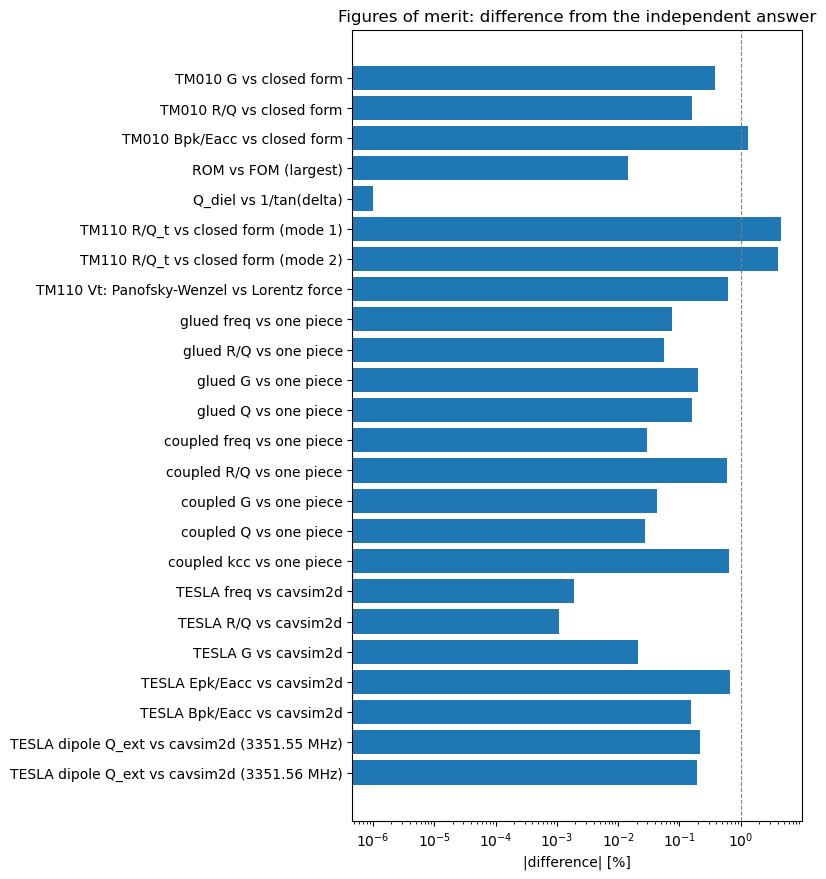

In [17]:
labels = list(summary)
values = [max(summary[k], 1e-6) for k in labels]
fig, ax = plt.subplots(figsize=(8, 0.32 * len(labels) + 1), layout="constrained")
ax.barh(labels, values, color="tab:blue")
ax.set_xscale("log")
ax.axvline(1.0, color="0.5", lw=0.8, ls="--")
ax.invert_yaxis()
ax.set_xlabel("|difference| [%]")
ax.set_title("Figures of merit: difference from the independent answer")
plt.show()

Every check is within 1 % except the transverse R/Q of the two TM110 polarisations
against a closed form that ignores the beam-pipe holes, and the peak magnetic field of
the pillbox with second-order elements. The `Q_diel` bar sits at the plot's floor: its
difference is rounding.

## What we did

We computed the figures of merit of pillbox and TESLA-cell eigenmodes and checked them
against closed forms, the direct Lorentz force, one-piece solutions and cavsim2d, and
the external Q of the loaded TESLA cell against cavsim2d's port boundary condition.

**Next:** [Get the figures of merit of resonances](../../how-to/resonance_figures.md)
for every option.

**Background:** [Ports and port modes](../../explanation/ports.md#loaded-resonances)
explains the magnetic walls at the ports and the loaded resonances.